Imports and Task 1 (Dataset Understanding)

Loading dataset from: c:\Users\vinnie\Desktop\part-1-neural-network-analysis\customer_churn_nn.csv
Shape: (2000, 17)

First 5 rows:
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usag

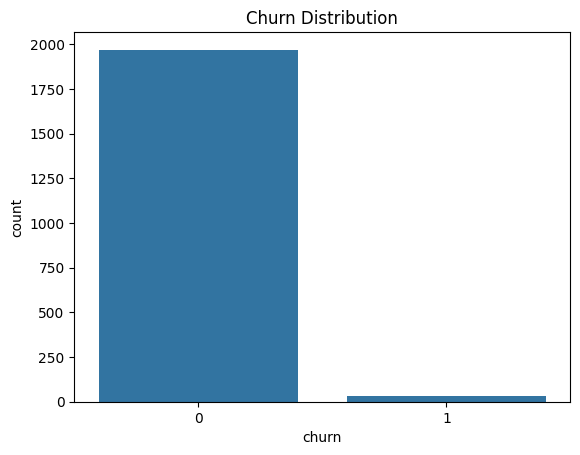

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import os

# Create results folder if it doesn't exist
os.makedirs('results', exist_ok=True)

# Load dataset
csv_path = r"c:\Users\vinnie\Desktop\part-1-neural-network-analysis\customer_churn_nn.csv"
print("Loading dataset from:", csv_path)
df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

# Target distribution
print("\nTarget distribution (churn):")
print(df['churn'].value_counts())
print("\nRelative frequencies:")
print(df['churn'].value_counts(normalize=True))

# Statistical summary
print("\nStatistical summary:")
df.describe()

# Plot target distribution
sns.countplot(x='churn', data=df)
plt.title('Churn Distribution')
plt.show()

Task 2 (Preprocessing)

In [8]:
# Drop identifier
X = df.drop(columns=['customer_id', 'churn'])
y = df['churn']

# Categorical and numerical columns
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
num_cols = [col for col in X.columns if col not in cat_cols]

# Preprocessor
preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), num_cols),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

X_processed = preprocessor.fit_transform(X)
print("Processed feature shape:", X_processed.shape)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Processed feature shape: (2000, 24)
Train size: 1600, Test size: 400


Task 3 (Build Neural Network)

In [9]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

c:\Users\vinnie\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,713 (14.50 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 0 (0.00 B)

Task 4 (Train and Evaluate)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9797 - loss: 0.2541 - val_accuracy: 0.9937 - val_loss: 0.0614
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0909 - val_accuracy: 0.9937 - val_loss: 0.0399
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0830 - val_accuracy: 0.9937 - val_loss: 0.0384
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.0778 - val_accuracy: 0.9937 - val_loss: 0.0370
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0745 - val_accuracy: 0.9937 - val_loss: 0.0372
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.0712 - val_accuracy: 0.9937 - val_loss: 0.0344
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.0686 - val_accuracy: 0.9937 - val_loss: 0.0353
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9820 - loss: 0.0651 - val_accuracy: 0.9937 - v

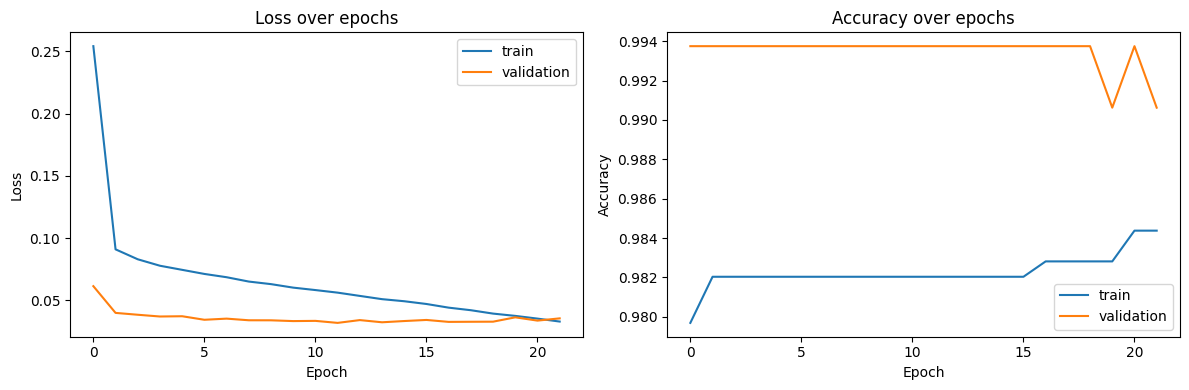

Test Loss: 0.0593
Test Accuracy: 0.9850
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


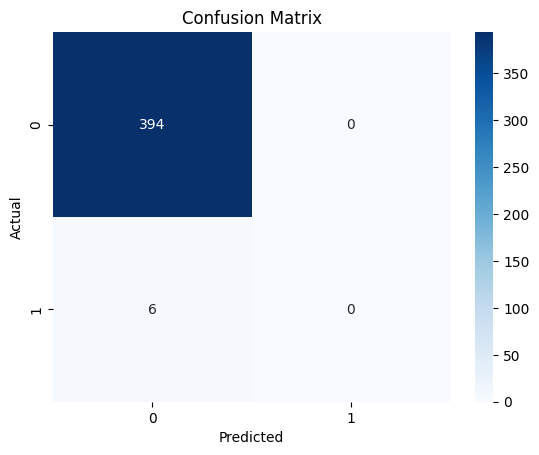


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



c:\Users\vinnie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vinnie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vinnie\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Plot training curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png')
plt.show()

# Test evaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix and report
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Task 5 (Hyperparameter Experiments)

In [11]:
# Helper function
def train_evaluate(hidden_layers, neurons_per_layer, lr, batch_size, epochs=50):
    tf.keras.backend.clear_session()
    model = Sequential()
    model.add(Dense(neurons_per_layer[0], activation='relu', input_shape=(X_train.shape[1],)))
    for neurons in neurons_per_layer[1:]:
        model.add(Dense(neurons, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    model.fit(X_train, y_train, validation_split=0.2, epochs=epochs, batch_size=batch_size, verbose=0)
    test_acc = model.evaluate(X_test, y_test, verbose=0)[1]
    return test_acc

# Experiment 1: Fewer neurons
acc1 = train_evaluate([1], [32], 0.001, 32)
# Experiment 2: High learning rate
acc2 = train_evaluate([2], [64,32], 0.01, 32)
# Experiment 3: Large batch size
acc3 = train_evaluate([2], [64,32], 0.001, 128)
# Experiment 4 (optional): Three hidden layers
acc4 = train_evaluate([3], [64,32,16], 0.001, 32)

comparison = pd.DataFrame({
    'Configuration': [
        'Baseline (64-32, lr=0.001, batch=32)',
        'Fewer neurons (32)',
        'High LR (0.01)',
        'Large batch (128)',
        '3 hidden layers (64-32-16)'
    ],
    'Test Accuracy': [test_acc, acc1, acc2, acc3, acc4]
})
print(comparison)
comparison.to_csv('results/model_comparison_table.csv', index=False)

c:\Users\vinnie\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


                          Configuration  Test Accuracy
0  Baseline (64-32, lr=0.001, batch=32)         0.9850
1                    Fewer neurons (32)         0.9875
2                        High LR (0.01)         0.9700
3                     Large batch (128)         0.9850
4            3 hidden layers (64-32-16)         0.9825


Task 6 (Reflection – as Markdown)

## Task 6: Final Reflection

**1. Role of weights and biases**  
Weights control the influence of each input on the neuron's output. Biases shift the activation function, allowing the network to fit data that does not pass through the origin.

**2. Why is an activation function required?**  
Without non‑linear activation functions (e.g., ReLU, sigmoid), the entire network would be equivalent to a linear model, unable to learn complex patterns.

**3. Effects of learning rate**  
- Too high: Loss oscillates or diverges → lower accuracy.  
- Too low: Very slow convergence, may get stuck in local minima.

**4. Overfitting / underfitting**  
Our model shows no underfitting (high training & validation accuracy). Overfitting is prevented by early stopping; validation accuracy does not drop while training accuracy keeps increasing.